# Painel de Análise de Vendas

Exercício da apostila - páginas 67 e 68

## Etapa 1 - Preparação e Importação de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

lojas = ['Loja Centro', 'Loja Norte', 'Loja Sul', 'Loja Shopping']
regiao_da_loja = {'Loja Centro': 'Centro', 'Loja Norte': 'Norte', 'Loja Sul': 'Sul', 'Loja Shopping': 'Centro'}
categoria_do_produto = {
    'Camiseta': 'Vestuário', 'Calça Jeans': 'Vestuário', 'Jaqueta': 'Vestuário',
    'Tênis': 'Calçados', 'Boné': 'Acessórios', 'Mochila': 'Acessórios'
}

n = 400
lista_lojas = np.random.choice(lojas, n)
lista_produtos = np.random.choice(list(categoria_do_produto.keys()), n)

vendas = pd.DataFrame({
    'data': pd.date_range('2024-01-01', '2024-12-31', periods=n),
    'loja': lista_lojas,
    'regiao': [regiao_da_loja[l] for l in lista_lojas],
    'produto': lista_produtos,
    'categoria': [categoria_do_produto[p] for p in lista_produtos],
    'quantidade': np.random.randint(1, 15, n).astype(float),
    'preco_unitario': np.round(np.random.uniform(20, 300, n), 2)
})

idx_nulos = np.random.choice(vendas.index, 10, replace=False)
vendas.loc[idx_nulos[:5], 'preco_unitario'] = np.nan
vendas.loc[idx_nulos[5:], 'quantidade'] = np.nan

vendas.to_csv('vendas.csv', index=False)

vendas = pd.read_csv('vendas.csv')
vendas['data'] = pd.to_datetime(vendas['data'])
vendas.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2024-01-01 00:00:00.000000,Loja Sul,Sul,Tênis,Calçados,14.0,168.36
1,2024-01-01 21:57:17.593984,Loja Shopping,Centro,Jaqueta,Vestuário,9.0,218.02
2,2024-01-02 19:54:35.187969,Loja Centro,Centro,Camiseta,Vestuário,12.0,234.98
3,2024-01-03 17:51:52.781954,Loja Sul,Sul,Tênis,Calçados,1.0,44.44
4,2024-01-04 15:49:10.375939,Loja Sul,Sul,Mochila,Acessórios,9.0,161.71


In [3]:
vendas['faturamento'] = vendas['quantidade'] * vendas['preco_unitario']
vendas.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento
0,2024-01-01 00:00:00.000000,Loja Sul,Sul,Tênis,Calçados,14.0,168.36,2357.04
1,2024-01-01 21:57:17.593984,Loja Shopping,Centro,Jaqueta,Vestuário,9.0,218.02,1962.18
2,2024-01-02 19:54:35.187969,Loja Centro,Centro,Camiseta,Vestuário,12.0,234.98,2819.76
3,2024-01-03 17:51:52.781954,Loja Sul,Sul,Tênis,Calçados,1.0,44.44,44.44
4,2024-01-04 15:49:10.375939,Loja Sul,Sul,Mochila,Acessórios,9.0,161.71,1455.39


In [4]:
vendas.info()
print(vendas.isnull().sum())
vendas.describe()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            400 non-null    datetime64[us]
 1   loja            400 non-null    str           
 2   regiao          400 non-null    str           
 3   produto         400 non-null    str           
 4   categoria       400 non-null    str           
 5   quantidade      395 non-null    float64       
 6   preco_unitario  395 non-null    float64       
 7   faturamento     390 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 25.1 KB
data               0
loja               0
regiao             0
produto            0
categoria          0
quantidade         5
preco_unitario     5
faturamento       10
dtype: int64


,data,quantidade,preco_unitario,faturamento
count,400,395.000000,395.000000,390.000000
mean,2024-07-01 11:59:59.999999,7.255696,165.288582,1201.416000
min,2024-01-01 00:00:00,1.000000,20.070000,29.200000
25%,2024-04-01 05:59:59.999999,4.000000,105.335000,453.037500
50%,2024-07-01 11:59:59.999999,7.000000,168.920000,976.705000
75%,2024-09-30 17:59:59.999999,11.000000,230.790000,1832.375000
max,2024-12-31 00:00:00,14.000000,299.820000,4162.200000
std,NaN,4.041402,78.353613,934.436924


In [5]:
vendas['preco_unitario'] = vendas['preco_unitario'].fillna(vendas['preco_unitario'].mean())
vendas['quantidade'] = vendas['quantidade'].fillna(vendas['quantidade'].mean())
vendas['faturamento'] = vendas['quantidade'] * vendas['preco_unitario']
vendas.isnull().sum()

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64

## Etapa 2 - Análise Exploratória e Estatísticas

In [6]:
faturamento_loja = vendas.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
faturamento_loja

loja
Loja Sul         134169.620253
Loja Shopping    128299.571924
Loja Centro      113070.502759
Loja Norte       105180.553949
Name: faturamento, dtype: float64

In [7]:
qtd_vendas_loja = vendas.groupby('loja')['faturamento'].count()
ticket_medio = faturamento_loja / qtd_vendas_loja
ticket_medio

loja
Loja Centro      1190.215819
Loja Norte       1223.029697
Loja Shopping    1115.648452
Loja Sul         1290.092502
Name: faturamento, dtype: float64

In [8]:
top5_produtos = vendas.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(5)
top5_produtos

produto
Boné           555.000000
Tênis          527.000000
Camiseta       510.511392
Calça Jeans    472.000000
Mochila        460.511392
Name: quantidade, dtype: float64

In [9]:
vendas['mes_ano'] = vendas['data'].dt.strftime('%m/%Y')
faturamento_mes_ano = vendas.groupby('mes_ano')['faturamento'].sum()

mes_maior = faturamento_mes_ano.idxmax()
mes_menor = faturamento_mes_ano.idxmin()

print(f'Maior faturamento: {mes_maior} (R$ {faturamento_mes_ano.max():.2f})')
print(f'Menor faturamento: {mes_menor} (R$ {faturamento_mes_ano.min():.2f})')

Maior faturamento: 09/2024 (R$ 44927.24)
Menor faturamento: 04/2024 (R$ 30062.89)


In [10]:
vendas['mes'] = vendas['data'].dt.month
vendas.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento,mes_ano,mes
0,2024-01-01 00:00:00.000000,Loja Sul,Sul,Tênis,Calçados,14.0,168.36,2357.04,01/2024,1
1,2024-01-01 21:57:17.593984,Loja Shopping,Centro,Jaqueta,Vestuário,9.0,218.02,1962.18,01/2024,1
2,2024-01-02 19:54:35.187969,Loja Centro,Centro,Camiseta,Vestuário,12.0,234.98,2819.76,01/2024,1
3,2024-01-03 17:51:52.781954,Loja Sul,Sul,Tênis,Calçados,1.0,44.44,44.44,01/2024,1
4,2024-01-04 15:49:10.375939,Loja Sul,Sul,Mochila,Acessórios,9.0,161.71,1455.39,01/2024,1


## Etapa 3 - Visualizações com matplotlib e seaborn

In [11]:
import os
os.makedirs('graficos', exist_ok=True)

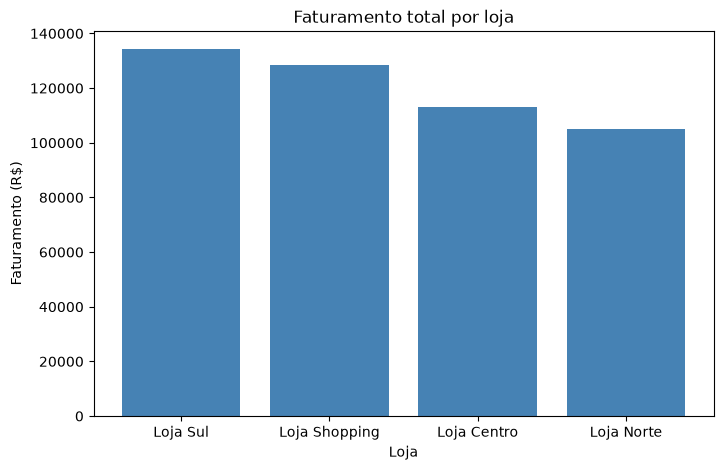

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(faturamento_loja.index, faturamento_loja.values, color='steelblue')
plt.title('Faturamento total por loja')
plt.xlabel('Loja')
plt.ylabel('Faturamento (R$)')
plt.savefig('graficos/faturamento_por_loja.png')
plt.show()

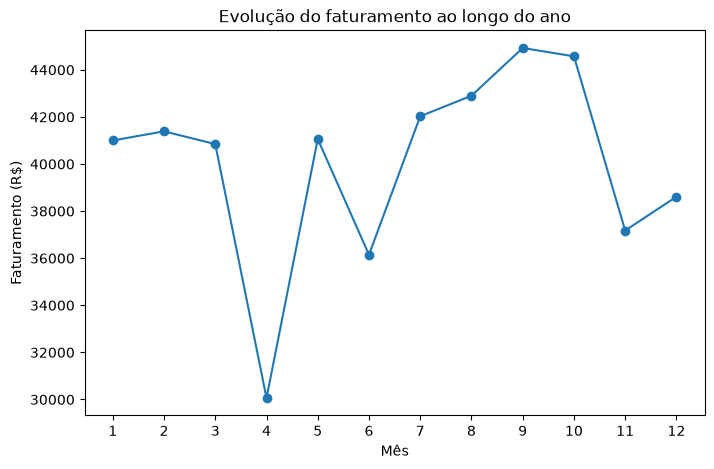

In [13]:
faturamento_mensal = vendas.groupby('mes')['faturamento'].sum()

plt.figure(figsize=(8, 5))
plt.plot(faturamento_mensal.index, faturamento_mensal.values, marker='o')
plt.title('Evolução do faturamento ao longo do ano')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.xticks(faturamento_mensal.index)
plt.savefig('graficos/evolucao_faturamento.png')
plt.show()

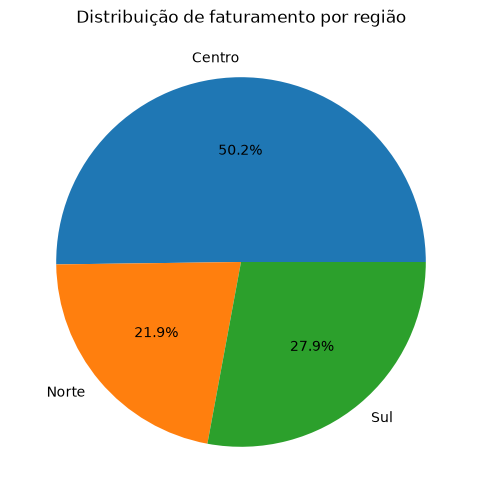

In [14]:
faturamento_regiao = vendas.groupby('regiao')['faturamento'].sum()

plt.figure(figsize=(6, 6))
plt.pie(faturamento_regiao, labels=faturamento_regiao.index, autopct='%1.1f%%')
plt.title('Distribuição de faturamento por região')
plt.savefig('graficos/faturamento_por_regiao.png')
plt.show()

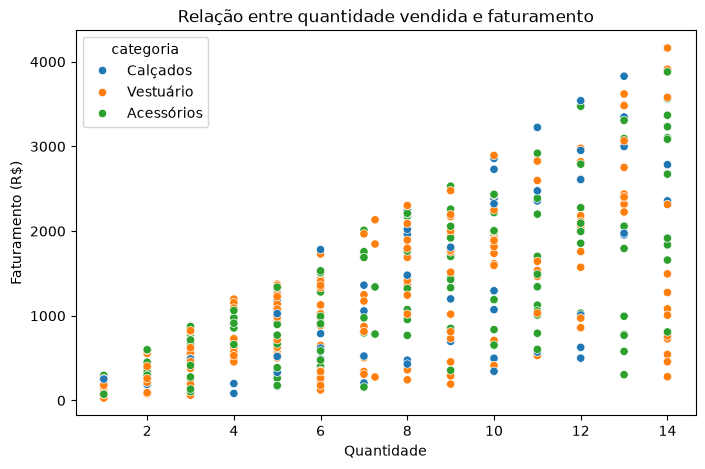

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=vendas, x='quantidade', y='faturamento', hue='categoria')
plt.title('Relação entre quantidade vendida e faturamento')
plt.xlabel('Quantidade')
plt.ylabel('Faturamento (R$)')
plt.savefig('graficos/quantidade_x_faturamento.png')
plt.show()

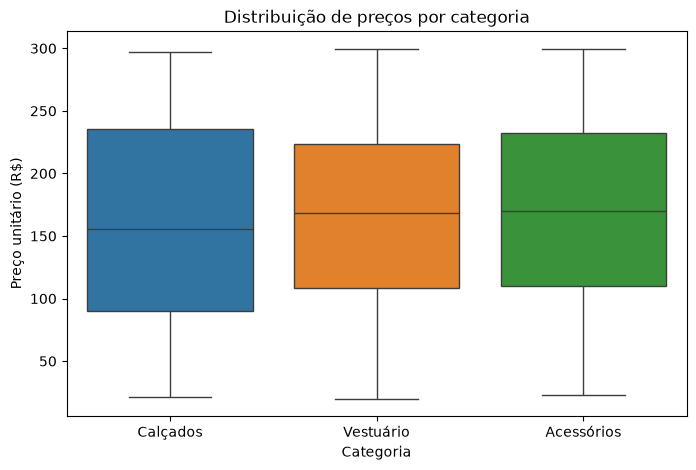

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=vendas, x='categoria', y='preco_unitario', hue='categoria', legend=False)
plt.title('Distribuição de preços por categoria')
plt.xlabel('Categoria')
plt.ylabel('Preço unitário (R$)')
plt.savefig('graficos/preco_por_categoria.png')
plt.show()

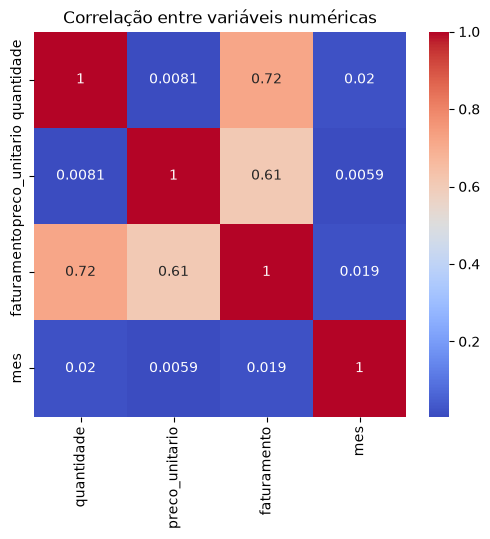

In [17]:
plt.figure(figsize=(6, 5))
correlacao = vendas[['quantidade', 'preco_unitario', 'faturamento', 'mes']].corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis numéricas')
plt.savefig('graficos/heatmap_correlacao.png')
plt.show()

## Etapa 4 - Estilização e Apresentação

In [18]:
sns.set_style('whitegrid')
sns.set_palette(sns.color_palette('deep'))

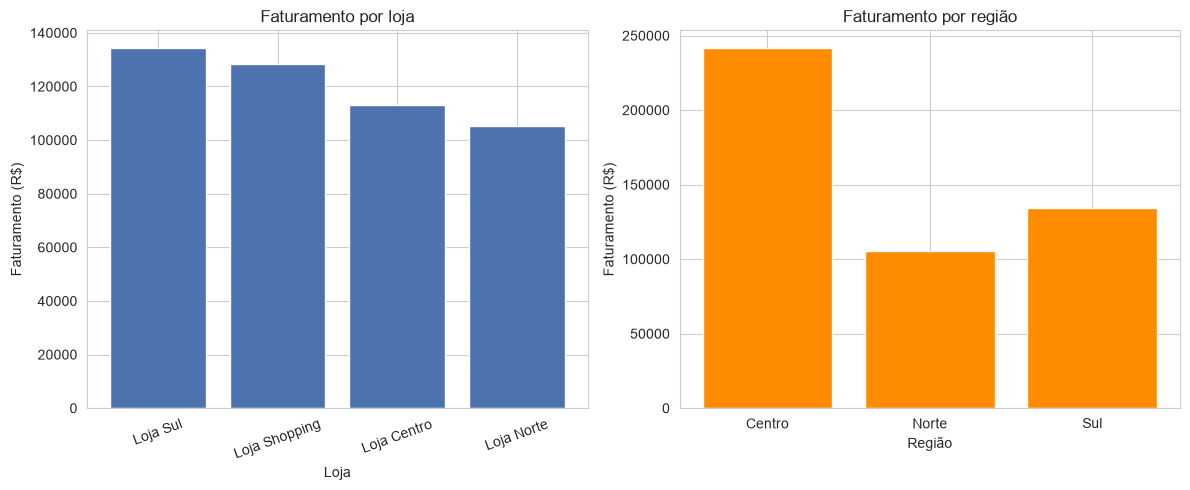

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].bar(faturamento_loja.index, faturamento_loja.values)
axs[0].set_title('Faturamento por loja')
axs[0].set_xlabel('Loja')
axs[0].set_ylabel('Faturamento (R$)')
axs[0].tick_params(axis='x', rotation=20)

axs[1].bar(faturamento_regiao.index, faturamento_regiao.values, color='darkorange')
axs[1].set_title('Faturamento por região')
axs[1].set_xlabel('Região')
axs[1].set_ylabel('Faturamento (R$)')

plt.tight_layout()
plt.savefig('graficos/comparativo_loja_regiao.png')
plt.show()

In [20]:
resumo_analitico = pd.DataFrame({
    'loja_maior_faturamento': [faturamento_loja.idxmax()],
    'loja_menor_faturamento': [faturamento_loja.idxmin()],
    'produto_mais_vendido': [top5_produtos.idxmax()],
    'mes_maior_faturamento': [mes_maior],
    'mes_menor_faturamento': [mes_menor],
    'ticket_medio_geral': [round(vendas['faturamento'].sum() / len(vendas), 2)]
})

resumo_analitico.to_csv('resumo_analitico.csv', index=False)
resumo_analitico

,loja_maior_faturamento,loja_menor_faturamento,produto_mais_vendido,mes_maior_faturamento,mes_menor_faturamento,ticket_medio_geral
0,Loja Sul,Loja Norte,Boné,09/2024,04/2024,1201.8


### Comentários finais

- A **Loja Sul** foi a que mais faturou, e a **Loja Norte** foi a que menos faturou no período.
- O produto mais vendido em quantidade foi o **Boné**.
- O mês de maior faturamento foi **09/2024** e o de menor foi **04/2024** - dá pra ver isso claramente no gráfico de linha.
- No gráfico de dispersão, dá pra notar que não existe uma relação linear muito forte entre quantidade e faturamento, porque o faturamento também depende bastante do preço de cada produto.
- O heatmap confirma isso: faturamento tem correlação forte com preço_unitario e com quantidade (o que é esperado, já que ele é o produto dos dois), mas quantidade e preço praticamente não se relacionam entre si.
- O ticket médio geral da rede ficou em torno de R$ 1.201,80.